<a href="https://colab.research.google.com/github/songnee/test/blob/main/6_RegularizationMethod.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 규제 (Regularization)

#### 1. 개념
- Regularization은 **OverFitting**을 방지하기 위해 사용됩니다.
- 모델의 파라미터 값에 패널티를 부여하여 모델이 과도하게 복잡해지지 않도록 적용.
- 일반적으로 손실 함수에 규제 항(term)을 추가하여 모델이 너무 많은 가중치를 가지는 것을 방지
- 규제의 주요 목적은 과대적합을 줄이고 모델의 일반화 성능을 향상시키는 것
- 선형 회귀 모델 → 모델의 가중치 제한
- 다항 회귀 모델 → 다항식의 차수 감소

#### 2. 주의점
- 규제 강도가 너무 높으면 모델이 과소적합(underfitting)될 수 있습니다.
- 적절한 규제 강도를 찾기 위해 하이퍼파라미터 튜닝이 필요합니다.
- 잘못된 규제 적용은 모델 성능을 저하시킬 수 있습니다.

#### 3. 규제 방법

1) **L1 규제 (Lasso Regularization)**
$$L = \text{Loss} + \lambda \sum_{i} |w_i|$$
- L1 규제는 손실 함수에 가중치의 절대값 합계를 더합니다.
- 모델의 복잡도를 줄이기 위해 일부 회귀 계수를 0으로 만들어 불필요한 변수를 제거
- 덜 중요한 특징을 제거하려고 하기 때문에 Lasso 규제가 Ridge 규제에 비해 더 강하게 규제
---
2) **L2 규제 (Ridge Regularization)**
$$L = \text{Loss} + \lambda \sum_{i} w_i^2$$
- 모든 회귀 계수의 크기를 작게 만들어(0에 가깝게) 과대적합을 방지
---
3) **Elastic Net**
$$L = \text{Loss} + \lambda_1 \sum_{i} |w_i| + \lambda_2 \sum_{i} w_i^2$$
- L1 규제와 L2 규제를 혼합하여 사용하는 방법
- L1 규제의 변수 선택 효과와 L2 규제의 안정화 효과를 동시에 얻을 수 있다.
---
4) Early Stopping

<img src="https://velog.velcdn.com/images/newnew_daddy/post/8afb5153-8525-4890-8c7e-6e6f768973c2/image.png" width="50%">

- 모델이 과대적합되기 전에 학습을 중단.
- 모델이 검증 데이터에서의 성능이 더 이상 향상되지 않을 때 학습을 중단하여 과대적합을 방지
- **검증 오차가 최솟값**에 도달하면 **훈련을 중단.**(오차의 상승이 확인되면 최솟값에 해당하는 파라미터를 복구)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

In [ ]:
# 시각화를 위한 연속 X값 생성
xx = np.linspace(0, 1, 100).reshape(-1, 1)
xx_poly = poly.transform(xx)

y_pred_linear = lr.predict(xx_poly)

plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.plot(xx, y_pred_linear, color='green', label='Linear Regression prediction')
plt.title('Linear Regression (degree=10, 규제 없음)')
plt.legend()
plt.show()

In [ ]:
df = pd.read_csv('./dataset/regularization.csv')

df.head()

,X,Y
0,0.020218,0.213138
1,0.071036,0.357444
2,0.087129,0.747487
3,0.118274,0.531167
4,0.143353,0.788347


In [ ]:
X = df['X'].to_frame()
y = df['Y'].to_frame()

X.shape, y.shape

((30, 1), (30, 1))

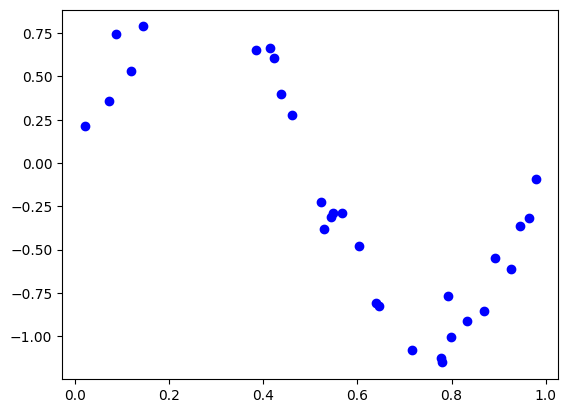

In [ ]:
plt.scatter(X, y, color='blue')

plt.show()

In [ ]:
# 학습/테스트 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((21, 1), (9, 1), (21, 1), (9, 1))

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=10, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
# np.linspace(0, 1, 100).reshape(-1,1)
poly.get_feature_names_out()

array(['X', 'X^2', 'X^3', 'X^4', 'X^5', 'X^6', 'X^7', 'X^8', 'X^9',
       'X^10'], dtype=object)

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_poly, y_train)

pred_train = lr.predict(X_train_poly)
pred_test = lr.predict(X_test_poly)

df_train = X_train.copy()

df_train['y_pred'] = pred_train

df_train = df_train.sort_values('X')


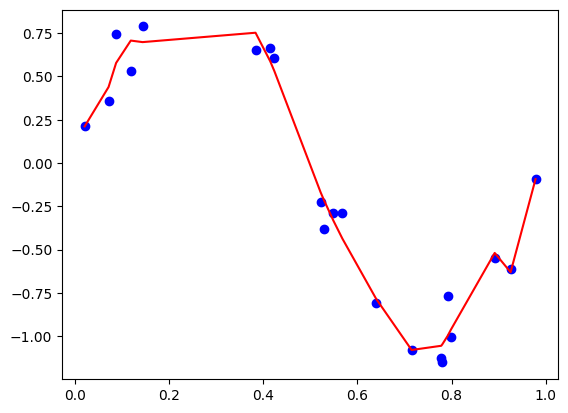

In [ ]:
plt.scatter(X_train, y_train, color='blue')
plt.plot(df_train['X'], df_train['y_pred'], color='red')
plt.show()

In [ ]:
## Train Score가 Test Score에 비해 훨씬 높아 과적합 되었다는 것을 확인할 수 있다.
print(f"TRAIN SCORE : {lr.score(X_train_poly, y_train)}")
print(f"TEST SCORE : {lr.score(X_test_poly, y_test)}")

TRAIN SCORE : 0.9759632231355843
TEST SCORE : 0.8325567427323918


#### 1. Lasso Regression (L1 Regularization)

In [ ]:
# Lasso Regression 모델 학습
lasso = Lasso(alpha=0.01)
lasso.fit(X_train_poly, y_train)

Lasso(alpha=0.01)

In [ ]:
lasso.get_params()

{'alpha': 0.01,
 'copy_X': True,
 'fit_intercept': True,
 'max_iter': 1000,
 'positive': False,
 'precompute': False,
 'random_state': None,
 'selection': 'cyclic',
 'tol': 0.0001,
 'warm_start': False}

In [ ]:
# Lasso 예측 (시각화용 연속 X값 사용)
xx_poly = poly.transform(xx)
y_pred_lasso = lasso.predict(xx_poly)

In [ ]:
lasso_mse = mean_squared_error(y_test, lasso.predict(X_test_poly))

print("Lasso Regression Test MSE:", lasso_mse)
print("Lasso Regression Coefficients:", lasso.coef_)

print(f"TRAIN SCORE : {lasso.score(X_train_poly, y_train)}")
print(f"TEST SCORE : {lasso.score(X_test_poly, y_test)}")

Lasso Regression Test MSE: 0.04459731287679361
Lasso Regression Coefficients: [ 0.         -0.         -2.52485252 -0.         -0.          0.
  0.          0.          0.          0.          1.93532916]
TRAIN SCORE : 0.8075143518606493
TEST SCORE : 0.7720877109400942


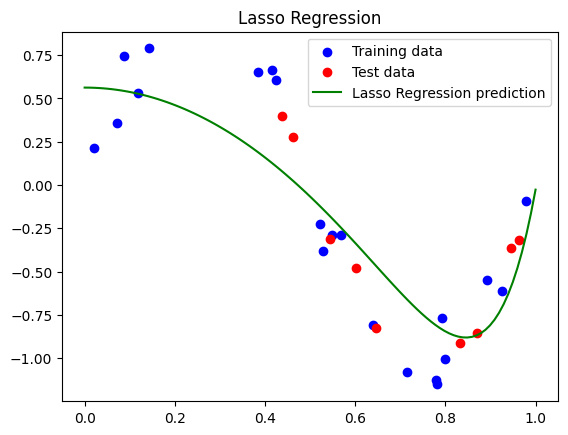

In [ ]:
# 시각화
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.plot(xx, y_pred_lasso, color='green', label='Lasso Regression prediction')
plt.title('Lasso Regression')
plt.legend()
plt.show()

#### 2. Ridge Regression (L2 Regularization)

In [ ]:
from sklearn.linear_model import Ridge

# Ridge Regression 모델 학습
ridge = Ridge(alpha=0.01)
ridge.fit(X_train_poly, y_train)

Ridge(alpha=0.01)

In [ ]:
# Ridge 예측 (시각화용 연속 X값 사용)
xx_poly = poly.transform(xx)
y_pred_ridge = ridge.predict(xx_poly)

In [ ]:
ridge_mse = mean_squared_error(y_test, ridge.predict(X_test_poly))

print("Ridge Regression Test MSE:", ridge_mse)
print("Ridge Regression Coefficients:", ridge.coef_)

print(f"TRAIN SCORE : {ridge.score(X_train_poly, y_train)}")
print(f"TEST SCORE : {ridge.score(X_test_poly, y_test)}")

Ridge Regression Test MSE: 0.02088159011227684
Ridge Regression Coefficients: [[ 0.          1.36152224 -3.5303547  -2.49423664 -0.59252922  0.74908971
   1.36580935  1.41863497  1.10484826  0.58210496 -0.04021061]]
TRAIN SCORE : 0.8905858773219614
TEST SCORE : 0.8932857005342991


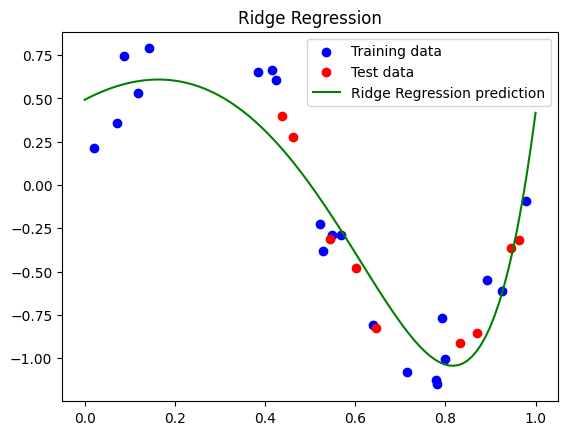

In [ ]:
# 시각화

plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.plot(xx, y_pred_ridge, color='green', label='Ridge Regression prediction')
plt.title('Ridge Regression')
plt.legend()
plt.show()

#### 3. ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet

# ElasticNet Regression 모델 학습
en = ElasticNet(alpha=0.001)
en.fit(X_train_poly, y_train)

ElasticNet(alpha=0.001)

In [ ]:
# ElasticNet 예측 (시각화용 연속 X값 사용)
xx_poly = poly.transform(xx)
y_pred_en = en.predict(xx_poly)

In [ ]:
en_mse = mean_squared_error(y_test, en.predict(X_test_poly))

print("ElasticNet Test MSE:", en_mse)
print("ElasticNet Coefficients:", en.coef_)

print(f"TRAIN SCORE : {en.score(X_train_poly, y_train)}")
print(f"TEST SCORE : {en.score(X_test_poly, y_test)}")

ElasticNet Test MSE: 0.023333870934116013
ElasticNet Coefficients: [ 0.          0.87588822 -3.03482061 -2.12220098 -0.          0.
  0.76420278  1.13921391  1.10115413  0.79912744  0.33854262]
TRAIN SCORE : 0.8779592683714081
TEST SCORE : 0.8807534446769311


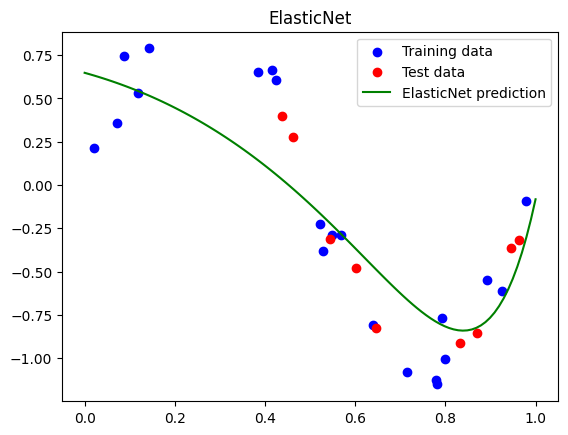

In [ ]:
# 시각화

plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.plot(xx, y_pred_en, color='green', label='ElasticNet prediction')
plt.title('ElasticNet')
plt.legend()
plt.show()

#### 4. 규제 시각화 비교

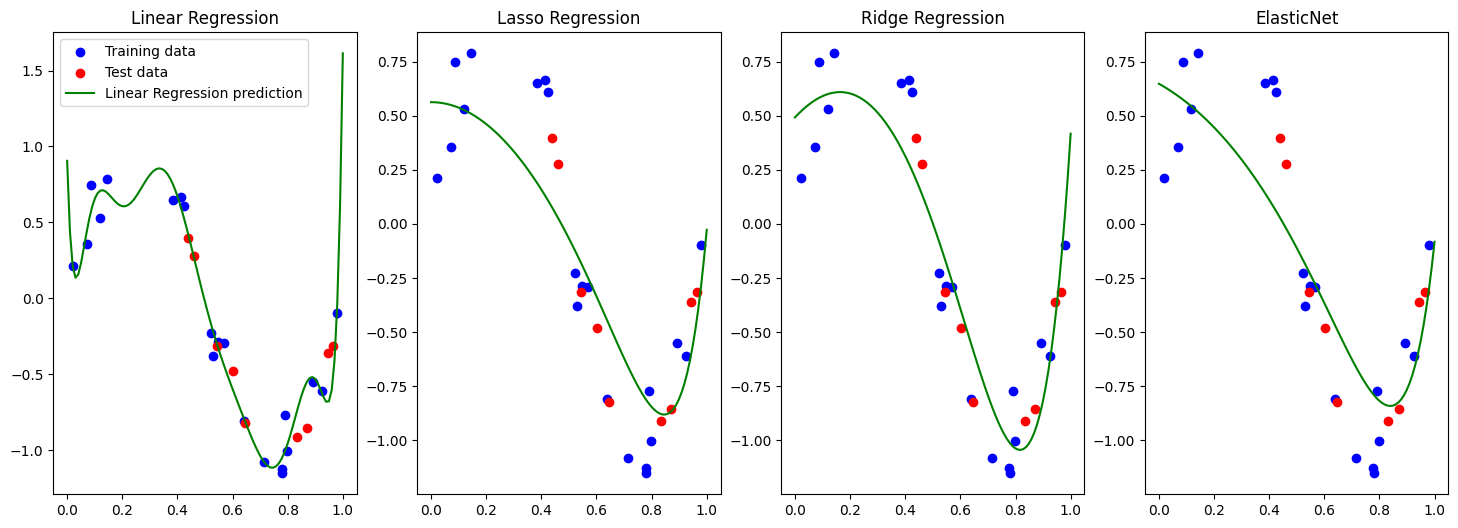

In [ ]:
plt.figure(figsize=(18, 6))

plt.subplot(1,4,1)
plt.scatter(X_train, y_train, color='blue', label='Training data')
plt.scatter(X_test, y_test, color='red', label='Test data')
plt.plot(xx, y_pred_linear, color='green', label='Linear Regression prediction')
plt.title('Linear Regression')
plt.legend()

plt.subplot(1,4,2)
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_test, y_test, color='red')
plt.plot(xx, y_pred_lasso, color='green')
plt.title('Lasso Regression')

plt.subplot(1,4,3)
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_test, y_test, color='red')
plt.plot(xx, y_pred_ridge, color='green')
plt.title('Ridge Regression')

plt.subplot(1,4,4)
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_test, y_test, color='red')
plt.plot(xx, y_pred_en, color='green')
plt.title('ElasticNet')
plt.show()